# ML - Iris Classification

This project was undertaken as an introductory study to develop a foundational understanding of Machine Learning concepts and methodologies, including exploratory data analysis, data preprocessing, feature engineering, feature scaling, and model development.

## Objective 

This notebook aims to develop a supervised machine learning model to classify Iris flowers into three species: 
- **Iris setosa** 
- **Iris versicolor** 
- **Iris virginica** 

The classification is based on four features: sepal length, sepal width, petal length, and petal width.


## Objective

This notebook focuses exclusively on the development, evaluation, and comparison of supervised classification models for the Iris dataset.

The prepared training and testing datasets generated during the preprocessing stage are used to train multiple classifiers and assess their predictive performance.

Final objective is to produce a optimized model with the best F1-score

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [84]:
prepared_data = joblib.load("data/iris_prepared.pkl")

X_train = prepared_data["X_train"]
X_test = prepared_data["X_test"]
y_train_encoded = prepared_data["y_train_encoded"]
y_test_encoded = prepared_data["y_test_encoded"]
X_train_scaled = prepared_data["X_train_scaled"]
X_test_scaled = prepared_data["X_test_scaled"]

encoder = prepared_data["encoder"]
scaler = prepared_data["scaler"]

In [85]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train_encoded)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test_encoded, y_pred_lr)


Accuracy: 0.9333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



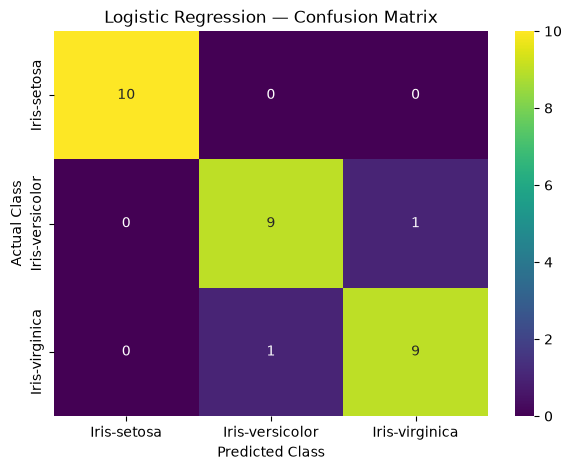

In [86]:
print(f"Accuracy: {lr_accuracy:.4f}")

print(
    classification_report(
        y_test_encoded,
        y_pred_lr,
        target_names=encoder.classes_
    )
)

cm_lr = confusion_matrix(y_test_encoded, y_pred_lr)

plt.figure(figsize=(7, 5))

sb.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [87]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train_encoded)
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test_encoded, y_pred_dt)


Accuracy: 0.9333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



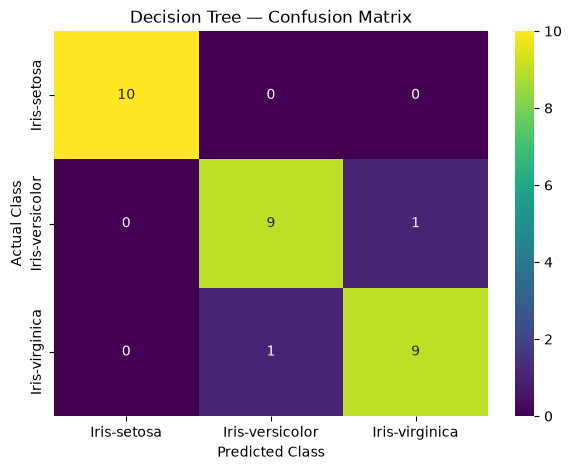

In [88]:
print(f"Accuracy: {dt_accuracy:.4f}")

print(
    classification_report(
        y_test_encoded,
        y_pred_dt,
        target_names=encoder.classes_
    )
)

cm_dt = confusion_matrix(y_test_encoded, y_pred_dt)

plt.figure(figsize=(7, 5))

sb.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Decision Tree — Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [89]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train_encoded)
y_pred_knn = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test_encoded, y_pred_knn)

In [90]:
print(f"Accuracy: {knn_accuracy:.4f}")

print(
    classification_report(
        y_test_encoded,
        y_pred_knn,
        target_names=encoder.classes_
    )
)

Accuracy: 0.9333
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



In [91]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train_encoded)
y_pred_svm = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test_encoded, y_pred_svm)

In [92]:
print(f"Accuracy: {svm_accuracy:.4f}")

print(
    classification_report(
        y_test_encoded,
        y_pred_svm,
        target_names=encoder.classes_
    )
)

Accuracy: 0.9667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.967,0.970,0.967,0.967
1,Logistic Regression,0.933,0.933,0.933,0.933
2,Decision Tree,0.933,0.933,0.933,0.933
3,KNN,0.933,0.944,0.933,0.933


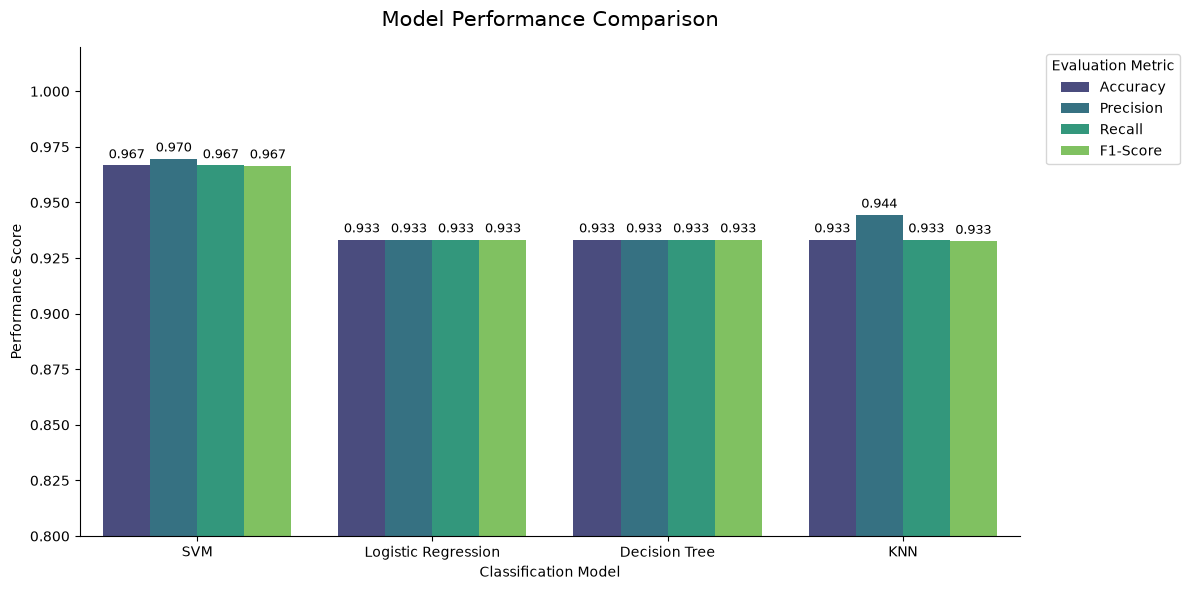

Best Model: SVM


In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_results = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm
}

models_results = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm
}

results = []

for model_name, predictions in models_results.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_encoded,
            predictions
        ),
        "Precision": precision_score(
            y_test_encoded,
            predictions,
            average="macro"
        ),
        "Recall": recall_score(
            y_test_encoded,
            predictions,
            average="macro"
        ),
        "F1-Score": f1_score(
            y_test_encoded,
            predictions,
            average="macro"
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1-Score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1-Score": "{:.3f}"
    })
)

results_plot = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

ax = sb.barplot(
    data=results_plot,
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)

plt.ylim(0.80, 1.02)

plt.title(
    "Model Performance Comparison",
    fontsize=15,
    pad=15
)

plt.xlabel("Classification Model")
plt.ylabel("Performance Score")

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

sb.despine()
plt.tight_layout()
plt.show()

best_model = results_df.iloc[0]
print(f"Best Model: {best_model['Model']}")

In [94]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_search.fit(
    X_train_scaled,
    y_train_encoded
)

best_svm = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

Best parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation F1-score: 0.9831


Test Accuracy: 0.9667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



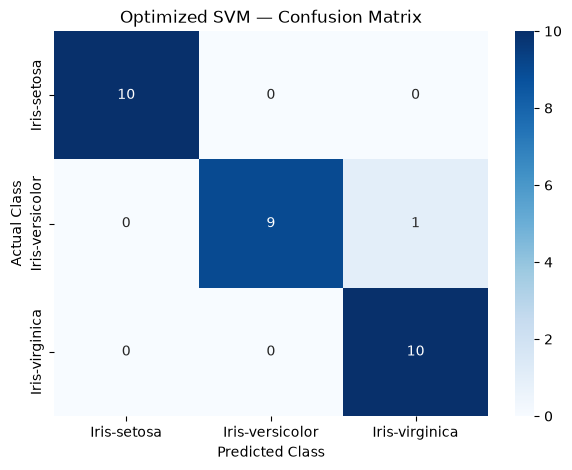

In [95]:
y_pred_best_svm = best_svm.predict(X_test_scaled)

print(
    f"Test Accuracy: "
    f"{accuracy_score(y_test_encoded, y_pred_best_svm):.4f}"
)

print(
    classification_report(
        y_test_encoded,
        y_pred_best_svm,
        target_names=encoder.classes_
    )
)

cm_best_svm = confusion_matrix(
    y_test_encoded,
    y_pred_best_svm
)

plt.figure(figsize=(7, 5))

sb.heatmap(
    cm_best_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Optimized SVM — Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [96]:
os.makedirs("models", exist_ok=True)

final_iris_model = {
    "model": best_svm,
    "scaler": scaler,
    "encoder": encoder,
    "features": X_train.columns.tolist()
}

joblib.dump(
    final_iris_model,
    "models/iris_svm_final.joblib"
)

print("Final model saved successfully.")

Final model saved successfully.
